In [41]:
#imports libraries and reads data
import pandas as pd
import numpy as np
import ast

df = pd.read_csv("data/movies_metadata.csv", low_memory=False)


In [42]:
#fixes the column types
for col in ["id", "budget", "revenue", "runtime"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

# A few rows in this file are malformed and have no valid ID
df = df.dropna(subset=["id"])
df = df.drop_duplicates(subset="id")
print(df.shape)

(45433, 24)


In [43]:
# Keep only movies where budget and revenue are actually known
# (0 means "unknown" in this dataset; tiny values are usually entry errors)
movies = df[(df["budget"] >= 10_000) & (df["revenue"] >= 10_000)].copy()


In [44]:
# calculates profitability
movies["profitability"] = movies["revenue"] - movies["budget"]

# 1 if the movie made a profit, 0 if not
movies["is_profitable"] = (movies["profitability"] > 0).astype(int)

print(movies.shape)
print(movies["is_profitable"].value_counts())

(5275, 26)
is_profitable
1    3716
0    1559
Name: count, dtype: int64


In [45]:
import ast

# Release timing
movies["release_year"] = movies["release_date"].dt.year
movies["release_month"] = movies["release_date"].dt.month

# Part of a franchise? (1 = yes, 0 = no)
movies["is_franchise"] = movies["belongs_to_collection"].notna().astype(int)

# English-language film? (1 = yes, 0 = no)
movies["is_english"] = (movies["original_language"] == "en").astype(int)

# Genres: one yes/no column per genre
def parse_names(text):
    try:
        return "|".join(item["name"] for item in ast.literal_eval(text))
    except (ValueError, SyntaxError, TypeError):
        return ""
genre_dummies = movies["genres"].apply(parse_names).str.get_dummies(sep="|")

# Drop the few movies missing runtime or release date
movies.loc[movies["runtime"] <= 0, "runtime"] = np.nan
movies = movies.dropna(subset=["runtime", "release_year"])
print(movies.shape)

(5264, 30)


In [46]:
#defines a helper function for reading text in genres and production compaies
def parse_names(text):
    """Turn "[{'id': 18, 'name': 'Drama'}, ...]" into ['Drama', ...]"""
    try:
        return [item["name"] for item in ast.literal_eval(text)]
    except (ValueError, SyntaxError, TypeError):
        return []

In [47]:
#cleans up runtime and makes sure runtime is greater than 0
movies["runtime"] = pd.to_numeric(movies["runtime"], errors="coerce")
movies.loc[movies["runtime"] <= 0, "runtime"] = np.nan
print(movies["runtime"].isna().sum(), "movies missing runtime")

0 movies missing runtime


In [48]:
#converts release date to release year and release month
movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")
movies["release_year"] = movies["release_date"].dt.year
movies["release_month"] = movies["release_date"].dt.month
movies[["release_date", "release_year", "release_month"]].head()

,release_date,release_year,release_month
0,1995-10-30,1995,10
1,1995-12-15,1995,12
3,1995-12-22,1995,12
5,1995-12-15,1995,12
8,1995-12-22,1995,12


In [49]:
# is franchise? 1 yes 2 no
movies["is_franchise"] = movies["belongs_to_collection"].notna().astype(int)
print(movies["is_franchise"].value_counts())

is_franchise
0    4049
1    1215
Name: count, dtype: int64


In [50]:
# is english? 1 yes 2 no 
movies["is_english"] = (movies["original_language"] == "en").astype(int)
print(movies["is_english"].value_counts())

is_english
1    4712
0     552
Name: count, dtype: int64


In [51]:
#is major studio? 
major_keywords = ["Warner", "Universal", "Paramount", "Fox", "Columbia", "Sony", "Disney"]

movies["company_list"] = movies["production_companies"].apply(parse_names)
movies["is_major_studio"] = movies["company_list"].apply(
    lambda companies: int(any(k in c for c in companies for k in major_keywords)))

print(movies["is_major_studio"].value_counts())

is_major_studio
0    3133
1    2131
Name: count, dtype: int64


In [52]:
#one column per genre
movies["genre_list"] = movies["genres"].apply(parse_names)
genre_dummies = movies["genre_list"].str.join("|").str.get_dummies(sep="|")
movies = pd.concat([movies, genre_dummies], axis=1)

print(len(genre_dummies.columns), "genres:", list(genre_dummies.columns))

20 genres: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


In [53]:
# drop movies with missing values
movies = movies.dropna(subset=["runtime", "release_year"])
print(movies.shape)

check_cols = ["budget", "runtime", "release_year", "release_month",
              "is_franchise", "is_english", "is_major_studio"]
print(movies[check_cols].isna().sum())

(5264, 53)
budget             0
runtime            0
release_year       0
release_month      0
is_franchise       0
is_english         0
is_major_studio    0
dtype: int64


is_profitable
1    3710
0    1554
Name: count, dtype: int64
is_profitable
1    0.705
0    0.295
Name: proportion, dtype: float64


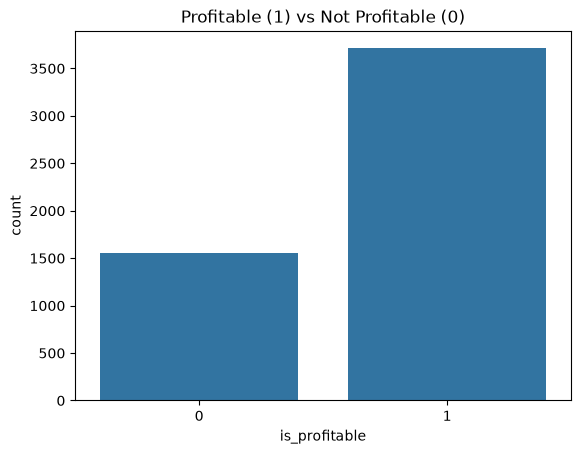

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

print(movies["is_profitable"].value_counts())
print(movies["is_profitable"].value_counts(normalize=True).round(3))

sns.countplot(data=movies, x="is_profitable")
plt.title("Profitable (1) vs Not Profitable (0)")
plt.show()

In [55]:
movies[["budget", "runtime", "release_year", "profitability"]].describe().round(1)

,budget,runtime,release_year,profitability
count,5264.0,5264.0,5264.0,5.264000e+03
mean,31709833.3,110.3,1999.8,6.054177e+07
std,40379273.6,21.5,15.8,1.407808e+08
min,10000.0,26.0,1915.0,-1.657101e+08
25%,6000000.0,95.0,1994.0,-1.436657e+06
50%,17500000.0,106.0,2004.0,1.198659e+07
75%,40000000.0,120.0,2011.0,6.448315e+07
max,380000000.0,338.0,2017.0,2.550965e+09


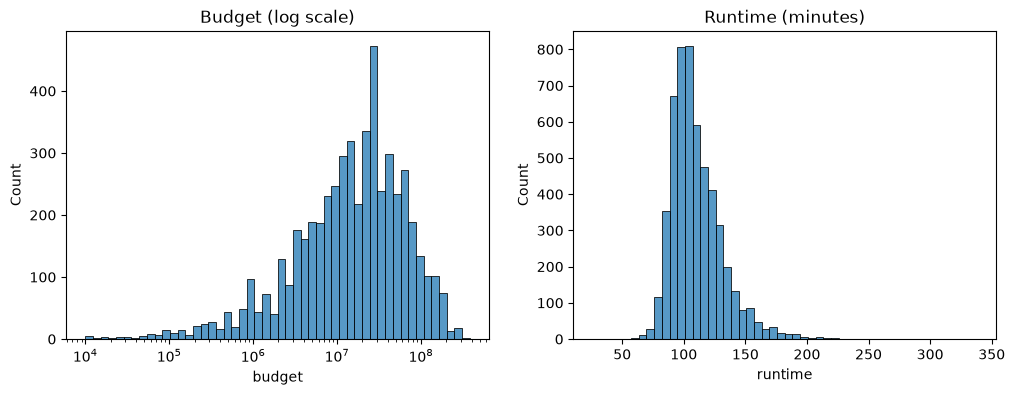

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(movies["budget"], bins=50, log_scale=True, ax=axes[0])
axes[0].set_title("Budget (log scale)")
sns.histplot(movies["runtime"], bins=50, ax=axes[1])
axes[1].set_title("Runtime (minutes)")
plt.show()

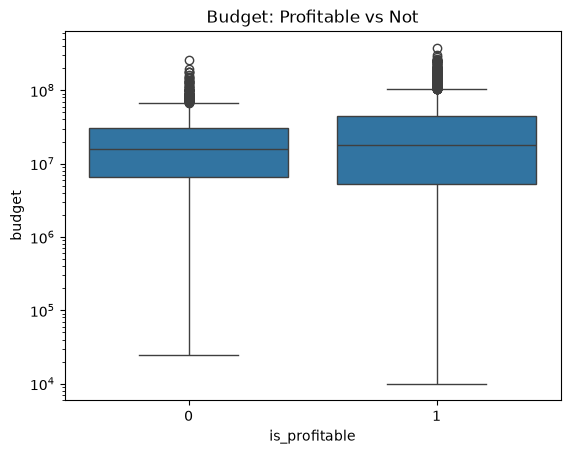

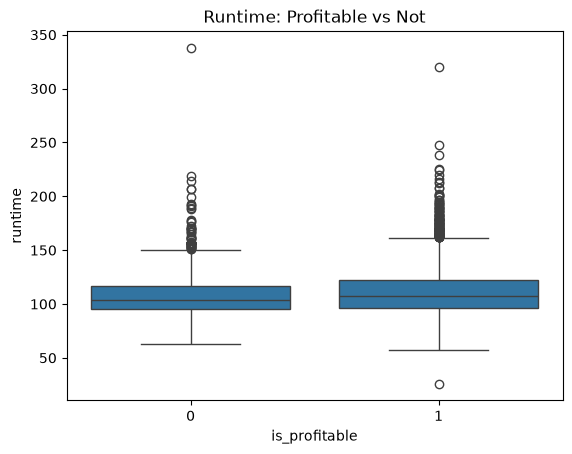

In [57]:
sns.boxplot(data=movies, x="is_profitable", y="budget")
plt.yscale("log")
plt.title("Budget: Profitable vs Not")
plt.show()

sns.boxplot(data=movies, x="is_profitable", y="runtime")
plt.title("Runtime: Profitable vs Not")
plt.show()

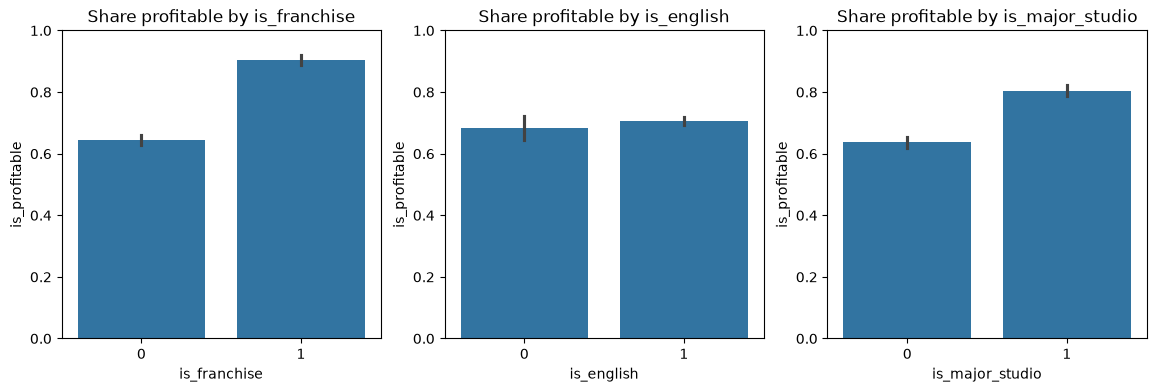

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["is_franchise", "is_english", "is_major_studio"]):
    sns.barplot(data=movies, x=col, y="is_profitable", ax=ax)
    ax.set_title(f"Share profitable by {col}")
    ax.set_ylim(0, 1)
plt.show()

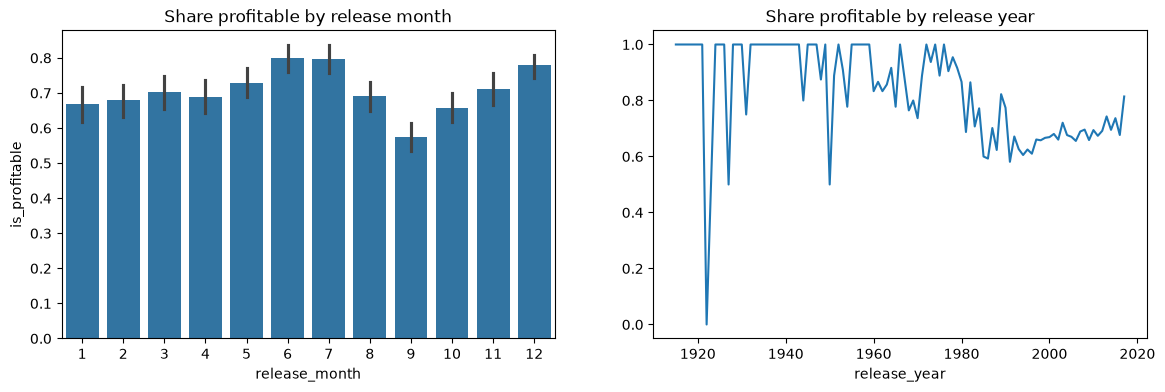

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=movies, x="release_month", y="is_profitable", ax=axes[0])
axes[0].set_title("Share profitable by release month")

movies.groupby("release_year")["is_profitable"].mean().plot(ax=axes[1])
axes[1].set_title("Share profitable by release year")
plt.show()

In [60]:
genre_rates = pd.DataFrame({
    "share_profitable": [movies.loc[movies[g] == 1, "is_profitable"].mean() for g in genre_dummies.columns],
    "num_movies": [movies[g].sum() for g in genre_dummies.columns]
}, index=genre_dummies.columns).sort_values("share_profitable")

genre_rates

,share_profitable,num_movies
Foreign,0.518519,27
Drama,0.652139,2524
Documentary,0.654545,55
History,0.655172,232
Mystery,0.659817,438
Music,0.682540,189
Thriller,0.687924,1474
Romance,0.704383,981
War,0.706468,201
Crime,0.706509,845


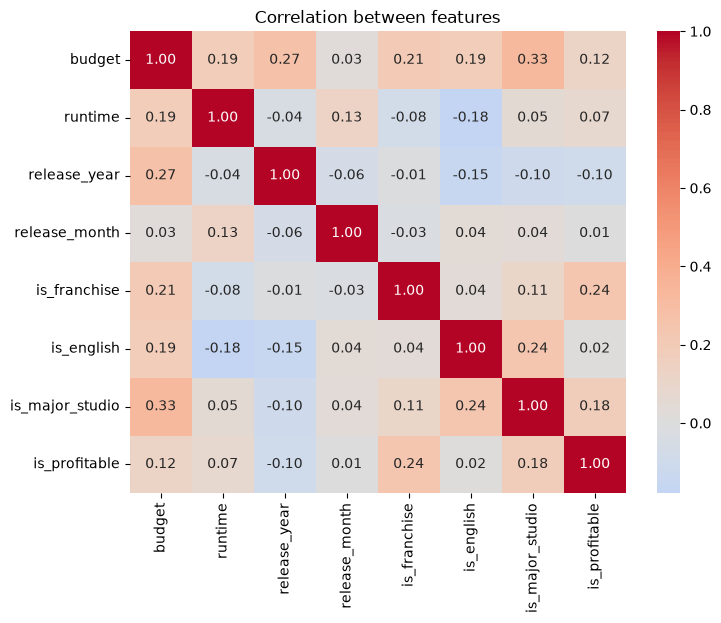

In [61]:
eda_cols = ["budget", "runtime", "release_year", "release_month",
            "is_franchise", "is_english", "is_major_studio", "is_profitable"]

plt.figure(figsize=(8, 6))
sns.heatmap(movies[eda_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between features")
plt.show()

In [62]:
#includes movies with only a certain number of ratings
for col in ["vote_average", "vote_count"]:
    movies[col] = pd.to_numeric(movies[col], errors="coerce")

# Ratings based on only a handful of votes aren't reliable
rated = movies[movies["vote_count"] >= 50].copy()
print(len(rated), "movies with at least 50 votes")

4335 movies with at least 50 votes


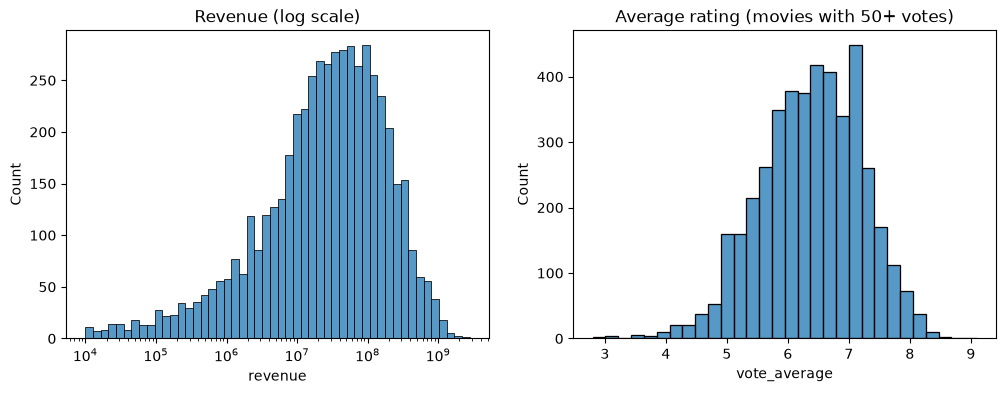

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(movies["revenue"], bins=50, log_scale=True, ax=axes[0])
axes[0].set_title("Revenue (log scale)")
sns.histplot(rated["vote_average"], bins=30, ax=axes[1])
axes[1].set_title("Average rating (movies with 50+ votes)")
plt.show()

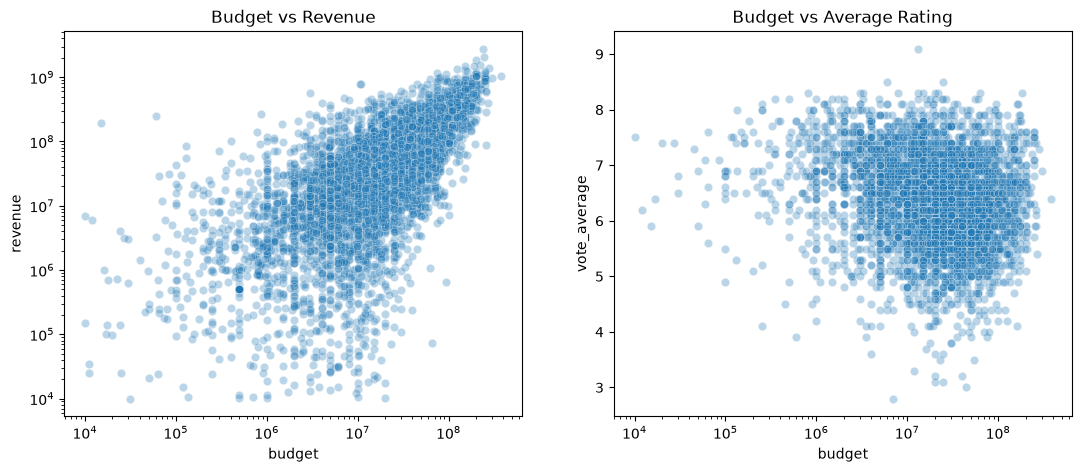

Budget vs revenue correlation: 0.73
Budget vs rating correlation: -0.08


In [64]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=movies, x="budget", y="revenue", alpha=0.3, ax=axes[0])
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_title("Budget vs Revenue")

sns.scatterplot(data=rated, x="budget", y="vote_average", alpha=0.3, ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("Budget vs Average Rating")
plt.show()

print("Budget vs revenue correlation:", round(movies["budget"].corr(movies["revenue"]), 2))
print("Budget vs rating correlation:", round(rated["budget"].corr(rated["vote_average"]), 2))

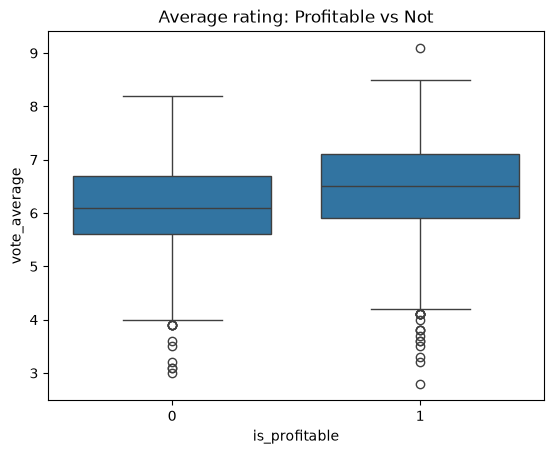

In [65]:
sns.boxplot(data=rated, x="is_profitable", y="vote_average")
plt.title("Average rating: Profitable vs Not")
plt.show()

In [66]:
rows = []
for g in genre_dummies.columns:
    subset = movies[movies[g] == 1]
    rows.append({
        "genre": g,
        "num_movies": len(subset),
        "share_profitable": subset["is_profitable"].mean(),
        "median_roi": (subset["revenue"] / subset["budget"]).median(),
        "avg_rating": rated.loc[rated[g] == 1, "vote_average"].mean(),
    })
genre_summary = pd.DataFrame(rows).sort_values("median_roi", ascending=False).round(2)
genre_summary

,genre,num_movies,share_profitable,median_roi,avg_rating
16,TV Movie,1,1.00,8.40,6.00
2,Animation,290,0.78,2.77,6.56
5,Documentary,55,0.65,2.60,6.95
11,Horror,578,0.74,2.52,5.90
7,Family,525,0.79,2.48,6.28
12,Music,189,0.68,2.45,6.54
1,Adventure,946,0.76,2.30,6.29
8,Fantasy,505,0.76,2.15,6.22
3,Comedy,1807,0.72,2.13,6.19
14,Romance,981,0.70,2.13,6.45


In [67]:
movies["decade"] = (movies["release_year"] // 10 * 10).astype(int)
rated["decade"] = (rated["release_year"] // 10 * 10).astype(int)

decade_summary = pd.DataFrame({
    "num_movies": movies.groupby("decade").size(),
    "share_profitable": movies.groupby("decade")["is_profitable"].mean(),
    "median_roi": (movies["revenue"] / movies["budget"]).groupby(movies["decade"]).median(),
    "avg_rating": rated.groupby("decade")["vote_average"].mean(),
}).round(2)
decade_summary

,num_movies,share_profitable,median_roi,avg_rating
decade,,,,
1910,4,1.00,36.00,6.40
1920,15,0.87,2.31,7.90
1930,34,0.97,3.81,7.42
1940,45,0.96,3.83,7.47
1950,74,0.91,4.57,7.39
1960,129,0.85,3.80,7.23
1970,186,0.92,6.53,6.94
1980,518,0.71,2.45,6.53
1990,919,0.65,1.75,6.36


In [68]:
movies["country_list"] = movies["production_countries"].apply(parse_names)
by_country = movies.explode("country_list")
top = by_country["country_list"].value_counts().head(8).index

country_summary = (by_country[by_country["country_list"].isin(top)]
                   .groupby("country_list")
                   .agg(num_movies=("is_profitable", "size"),
                        share_profitable=("is_profitable", "mean"),
                        avg_rating=("vote_average", "mean"))
                   .sort_values("share_profitable", ascending=False).round(2))
country_summary

,num_movies,share_profitable,avg_rating
country_list,,,
India,175,0.83,6.47
United States of America,4323,0.72,6.25
Australia,119,0.69,6.12
United Kingdom,653,0.67,6.49
Canada,230,0.62,6.08
Germany,313,0.61,6.32
France,364,0.55,6.44
Italy,106,0.55,6.50


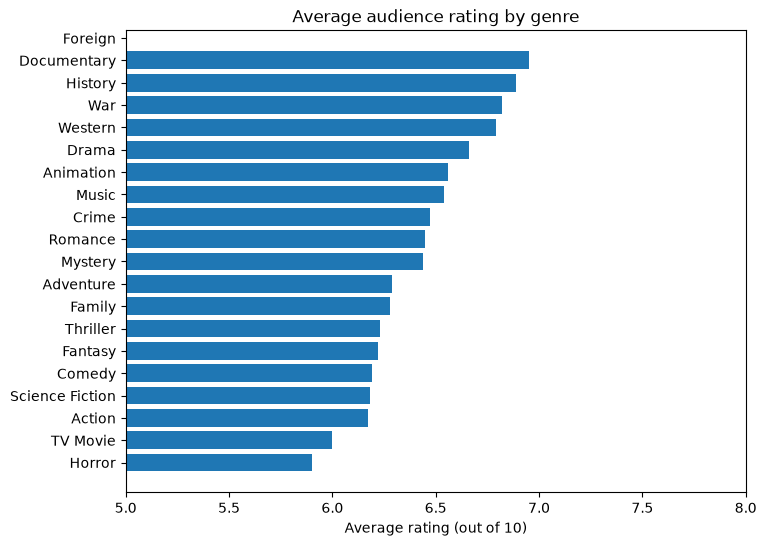

In [69]:
genre_plot = genre_summary.sort_values("avg_rating")
plt.figure(figsize=(8, 6))
plt.barh(genre_plot["genre"], genre_plot["avg_rating"])
plt.xlabel("Average rating (out of 10)")
plt.title("Average audience rating by genre")
plt.xlim(5, 8)
plt.show()

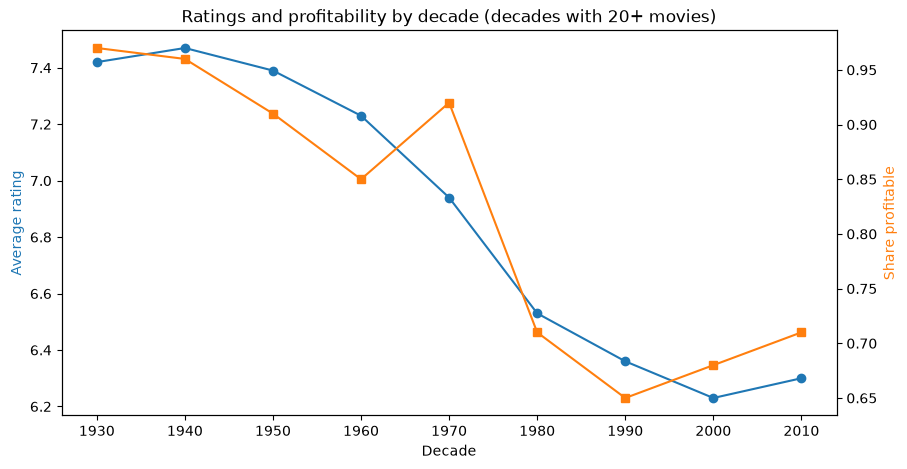

In [70]:
fig, ax1 = plt.subplots(figsize=(10, 5))
d = decade_summary[decade_summary["num_movies"] >= 20]
ax1.plot(d.index, d["avg_rating"], marker="o", color="tab:blue")
ax1.set_ylabel("Average rating", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(d.index, d["share_profitable"], marker="s", color="tab:orange")
ax2.set_ylabel("Share profitable", color="tab:orange")
ax1.set_xlabel("Decade")
plt.title("Ratings and profitability by decade (decades with 20+ movies)")
plt.show()

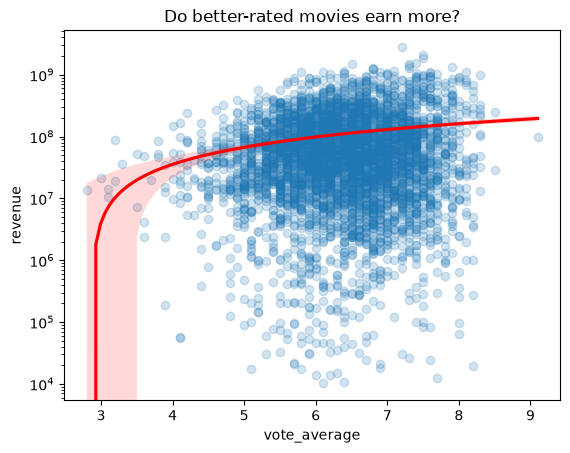

In [71]:
sns.regplot(data=rated, x="vote_average", y="revenue",
            scatter_kws={"alpha": 0.2}, line_kws={"color": "red"}, logistic=False)
plt.yscale("log")
plt.title("Do better-rated movies earn more?")
plt.show()

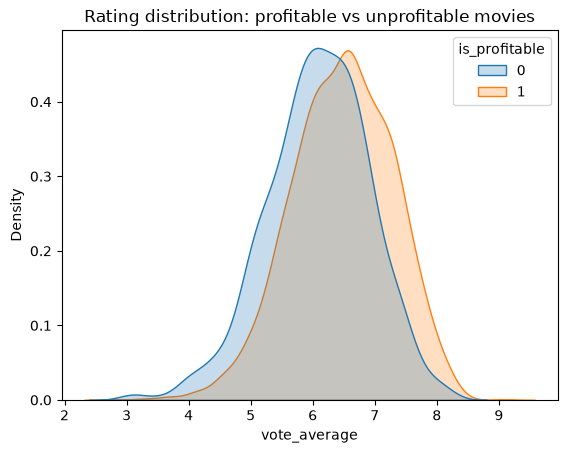

In [72]:
sns.kdeplot(data=rated, x="vote_average", hue="is_profitable", common_norm=False, fill=True)
plt.title("Rating distribution: profitable vs unprofitable movies")
plt.show()

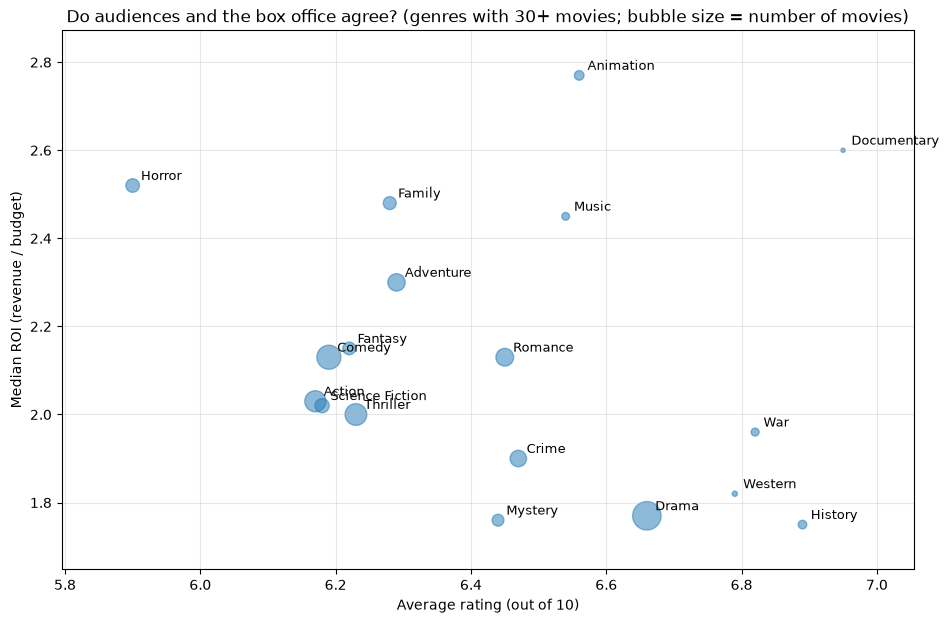

In [73]:
plot_data = genre_summary[genre_summary["num_movies"] >= 30]

plt.figure(figsize=(11, 7))
plt.scatter(plot_data["avg_rating"], plot_data["median_roi"],
            s=plot_data["num_movies"] / 6, alpha=0.5)

for _, row in plot_data.iterrows():
    plt.annotate(row["genre"], (row["avg_rating"], row["median_roi"]),
                 xytext=(6, 4), textcoords="offset points", fontsize=9)

x_pad = (plot_data["avg_rating"].max() - plot_data["avg_rating"].min()) * 0.1
y_pad = (plot_data["median_roi"].max() - plot_data["median_roi"].min()) * 0.1
plt.xlim(plot_data["avg_rating"].min() - x_pad, plot_data["avg_rating"].max() + x_pad)
plt.ylim(plot_data["median_roi"].min() - y_pad, plot_data["median_roi"].max() + y_pad)

plt.xlabel("Average rating (out of 10)")
plt.ylabel("Median ROI (revenue / budget)")
plt.title("Do audiences and the box office agree? (genres with 30+ movies; bubble size = number of movies)")
plt.grid(alpha=0.3)
plt.show()

In [74]:
keywords = pd.read_csv("data/keywords.csv")
keywords["id"] = pd.to_numeric(keywords["id"], errors="coerce")
keywords = keywords.drop_duplicates(subset="id")
keywords["keyword_list"] = keywords["keywords"].apply(parse_names)

movies = movies.merge(keywords[["id", "keyword_list"]], on="id", how="left")
movies["keyword_list"] = movies["keyword_list"].apply(lambda x: x if isinstance(x, list) else [])

movies["keyword_list"].explode().value_counts().head(40)

keyword_list
duringcreditsstinger       313
woman director             274
based on novel             267
murder                     247
independent film           235
violence                   200
aftercreditsstinger        168
dystopia                   160
revenge                    140
sequel                     138
biography                  135
love                       130
sex                        127
police                     123
sport                      121
suspense                   118
friendship                 117
musical                    113
los angeles                111
nudity                     110
3d                         110
teenager                   109
new york                    98
alien                       92
drug                        91
prison                      91
female nudity               89
family                      81
remake                      79
dying and death             78
high school                 78
world war ii              

In [75]:
# Director of each movie, from credits.csv
credits = pd.read_csv("data/credits.csv")
credits["id"] = pd.to_numeric(credits["id"], errors="coerce")

def get_director(text):
    try:
        for person in ast.literal_eval(text):
            if person.get("job") == "Director":
                return person["name"]
    except (ValueError, SyntaxError, TypeError):
        pass
    return None

credits["director"] = credits["crew"].apply(get_director)
movies = movies.merge(credits[["id", "director"]].drop_duplicates("id"), on="id", how="left")

# Franchise name, from belongs_to_collection
def get_collection(text):
    try:
        return ast.literal_eval(text)["name"]
    except (ValueError, SyntaxError, TypeError, KeyError):
        return None
movies["collection"] = movies["belongs_to_collection"].apply(get_collection)

# Track record: using ONLY films released earlier
movies = movies.sort_values("release_date").reset_index(drop=True)

def track_record(group_col, prefix):
    g = movies.groupby(group_col)["is_profitable"]
    movies[f"{prefix}_prev_films"] = g.cumcount()
    movies[f"{prefix}_prev_hit_rate"] = g.transform(lambda s: s.shift(1).expanding().mean()).fillna(0)
    movies.loc[movies[group_col].isna(), [f"{prefix}_prev_films", f"{prefix}_prev_hit_rate"]] = 0

track_record("director", "director")
track_record("collection", "franchise")

movies[["title", "director", "director_prev_films", "director_prev_hit_rate",
        "franchise_prev_films", "franchise_prev_hit_rate"]].tail(10)

,title,director,director_prev_films,director_prev_hit_rate,franchise_prev_films,franchise_prev_hit_rate
5254,Baby Driver,Edgar Wright,4.0,0.750,0.0,0.0
5255,A Ghost Story,David Lowery,1.0,1.000,0.0,0.0
5256,War for the Planet of the Apes,Matt Reeves,3.0,1.000,2.0,1.0
5257,Dunkirk,Christopher Nolan,8.0,1.000,0.0,0.0
5258,Valerian and the City of a Thousand Planets,Luc Besson,8.0,0.875,0.0,0.0
5259,Atomic Blonde,David Leitch,0.0,0.000,0.0,0.0
5260,The Emoji Movie,Anthony Leondis,1.0,1.000,0.0,0.0
5261,The Dark Tower,Nikolaj Arcel,1.0,0.000,0.0,0.0
5262,Wind River,Taylor Sheridan,0.0,0.000,0.0,0.0
5263,Kidnap,Luis Prieto,0.0,0.000,0.0,0.0


In [76]:
feature_cols = ["budget", "runtime", "release_year", "release_month",
                "is_franchise", "is_english", "is_major_studio"] + list(genre_dummies.columns)

model_data = movies[["title"] + feature_cols + ["is_profitable"]]
model_data = model_data.sort_values("title").reset_index(drop=True)
model_data.to_csv("data/model_data.csv", index=False)

print(model_data.shape)
print([c for c in model_data.columns if "month" in c])

(5264, 29)
['release_month']


In [77]:
movies["roi"] = movies["revenue"] / movies["budget"]
movies["budget_tier"] = pd.cut(movies["budget"],
    bins=[0, 10e6, 40e6, 100e6, np.inf],
    labels=["Low (<$10M)", "Mid ($10-40M)", "Upper-mid ($40-100M)", "Blockbuster ($100M+)"])

tier_summary = movies.groupby("budget_tier", observed=True).agg(
    num_movies=("roi", "size"),
    share_profitable=("is_profitable", "mean"),
    median_roi=("roi", "median"),
    roi_25th_pct=("roi", lambda s: s.quantile(0.25)),
    median_profit_M=("profitability", lambda s: s.median() / 1e6),
    avg_rating=("vote_average", "mean"),
    median_votes=("vote_count", "median"),
).round(2)
tier_summary

,num_movies,share_profitable,median_roi,roi_25th_pct,median_profit_M,avg_rating,median_votes
budget_tier,,,,,,,
Low (<$10M),1930,0.70,2.45,0.73,3.51,6.40,97.5
Mid ($10-40M),2084,0.66,1.74,0.67,15.52,6.22,300.0
Upper-mid ($40-100M),925,0.74,1.94,0.98,59.94,6.15,681.0
Blockbuster ($100M+),325,0.92,2.77,1.86,247.85,6.40,2547.0


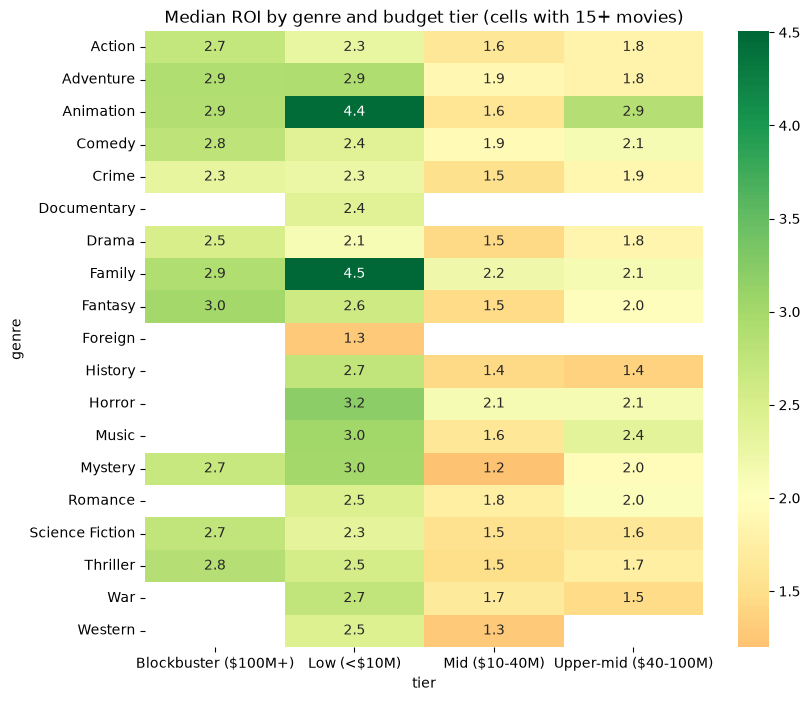

In [78]:
rows = []
for g in genre_dummies.columns:
    for tier, sub in movies[movies[g] == 1].groupby("budget_tier", observed=True):
        if len(sub) >= 15:
            rows.append({"genre": g, "tier": tier, "median_roi": sub["roi"].median()})

gt = pd.DataFrame(rows).pivot(index="genre", columns="tier", values="median_roi")
plt.figure(figsize=(9, 8))
sns.heatmap(gt, annot=True, fmt=".1f", cmap="RdYlGn", center=2)
plt.title("Median ROI by genre and budget tier (cells with 15+ movies)")
plt.show()

In [79]:
franchise_tier = movies.pivot_table(index="budget_tier", columns="is_franchise",
                                    values="is_profitable", aggfunc="mean", observed=True).round(2)
franchise_tier.columns = ["Original", "Franchise"]
franchise_tier

,Original,Franchise
budget_tier,,
Low (<$10M),0.66,0.88
Mid ($10-40M),0.60,0.88
Upper-mid ($40-100M),0.68,0.92
Blockbuster ($100M+),0.84,0.99


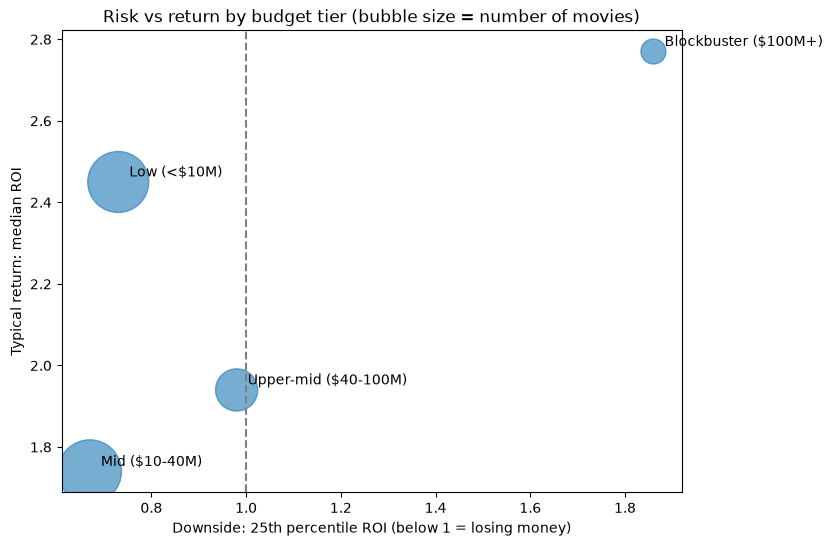

In [80]:
plt.figure(figsize=(8, 6))
plt.scatter(tier_summary["roi_25th_pct"], tier_summary["median_roi"],
            s=tier_summary["num_movies"], alpha=0.6)
for tier, row in tier_summary.iterrows():
    plt.annotate(tier, (row["roi_25th_pct"], row["median_roi"]),
                 xytext=(8, 4), textcoords="offset points")
plt.axvline(1, color="gray", linestyle="--")
plt.xlabel("Downside: 25th percentile ROI (below 1 = losing money)")
plt.ylabel("Typical return: median ROI")
plt.title("Risk vs return by budget tier (bubble size = number of movies)")
plt.show()

In [81]:
movies = movies.loc[:, ~movies.columns.duplicated()]

rec_cols = ["title", "budget", "revenue", "profitability", "is_profitable",
            "vote_count", "vote_average", "runtime", "release_year", "release_month",
            "is_franchise", "is_english", "is_major_studio"] + list(genre_dummies.columns)

movies[rec_cols].sort_values("title").to_csv("data/recommendation_data.csv", index=False)
print(movies[rec_cols].shape)

(5264, 33)


In [86]:
# Audience EDA setup: builds everything the audience charts need from `movies`
aud = movies.copy()
aud = aud.loc[:, ~aud.columns.duplicated()]
for col in ["vote_count", "vote_average"]:
    aud[col] = pd.to_numeric(aud[col], errors="coerce")

aud["budget_tier"] = pd.cut(aud["budget"], bins=[0, 10e6, 40e6, 100e6, np.inf],
    labels=["Low (<$10M)", "Mid ($10-40M)", "Upper-mid ($40-100M)", "Blockbuster ($100M+)"])
aud["log_votes"] = np.log10(aud["vote_count"].clip(lower=1))

rated = aud[aud["vote_count"] >= 50].copy()   # reliable ratings only
genre_cols = list(genre_dummies.columns)
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

df = aud   # the audience cells below use the name `df`

print(len(df), "movies |", len(rated), "with 50+ votes |", len(genre_cols), "genres")
print("Checks:", "is_franchise" in df.columns, df["vote_count"].dtype)

5264 movies | 4335 with 50+ votes | 20 genres
Checks: True float64


In [82]:
df["log_votes"] = np.log10(df["vote_count"].clip(lower=1))
rated["log_votes"] = df.loc[rated.index, "log_votes"]
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

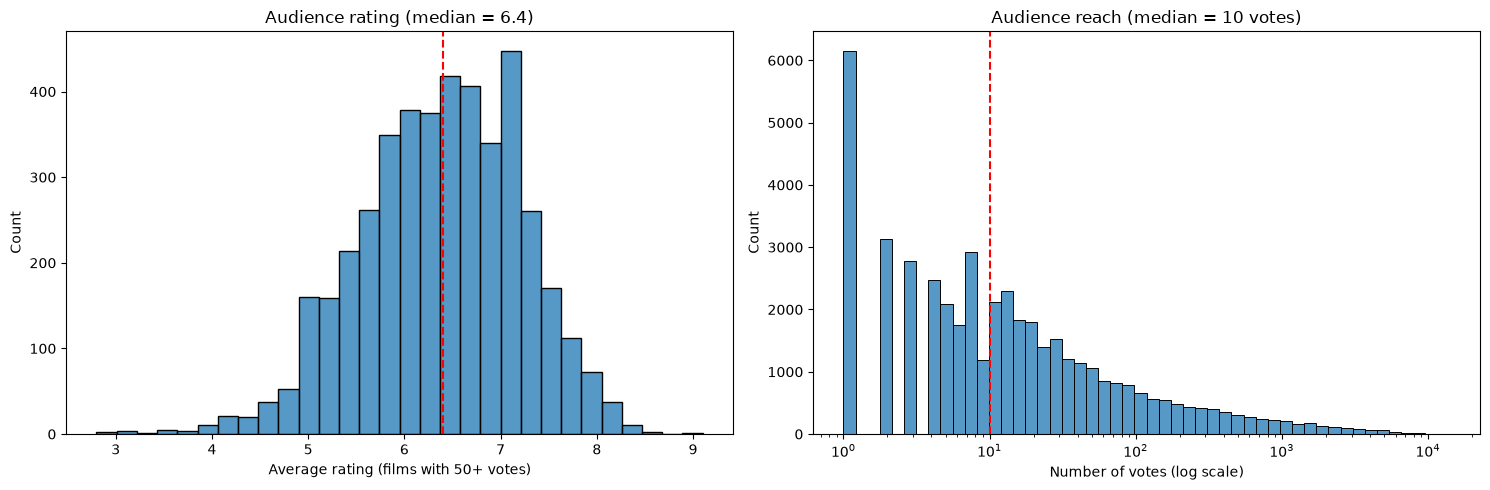

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(rated["vote_average"], bins=30, ax=axes[0])
axes[0].axvline(rated["vote_average"].median(), color="red", linestyle="--")
axes[0].set_title(f"Audience rating (median = {rated['vote_average'].median():.1f})")
axes[0].set_xlabel("Average rating (films with 50+ votes)")

sns.histplot(df["vote_count"].clip(lower=1), bins=50, log_scale=True, ax=axes[1])
axes[1].axvline(df["vote_count"].median(), color="red", linestyle="--")
axes[1].set_title(f"Audience reach (median = {df['vote_count'].median():.0f} votes)")
axes[1].set_xlabel("Number of votes (log scale)")
plt.tight_layout(); plt.show()

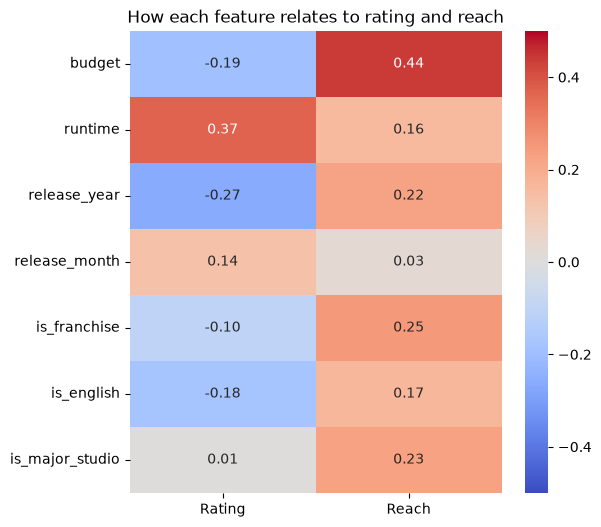

In [84]:
corr_cols = ["budget", "runtime", "release_year", "release_month",
             "is_franchise", "is_english", "is_major_studio"]
corr_data = rated[corr_cols + ["vote_average", "log_votes"]].copy()
corr_data["budget"] = np.log10(corr_data["budget"])

corr = corr_data.corr()[["vote_average", "log_votes"]].drop(["vote_average", "log_votes"])
corr.columns = ["Rating", "Reach"]

plt.figure(figsize=(6, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-0.5, vmax=0.5)
plt.title("How each feature relates to rating and reach")
plt.show()

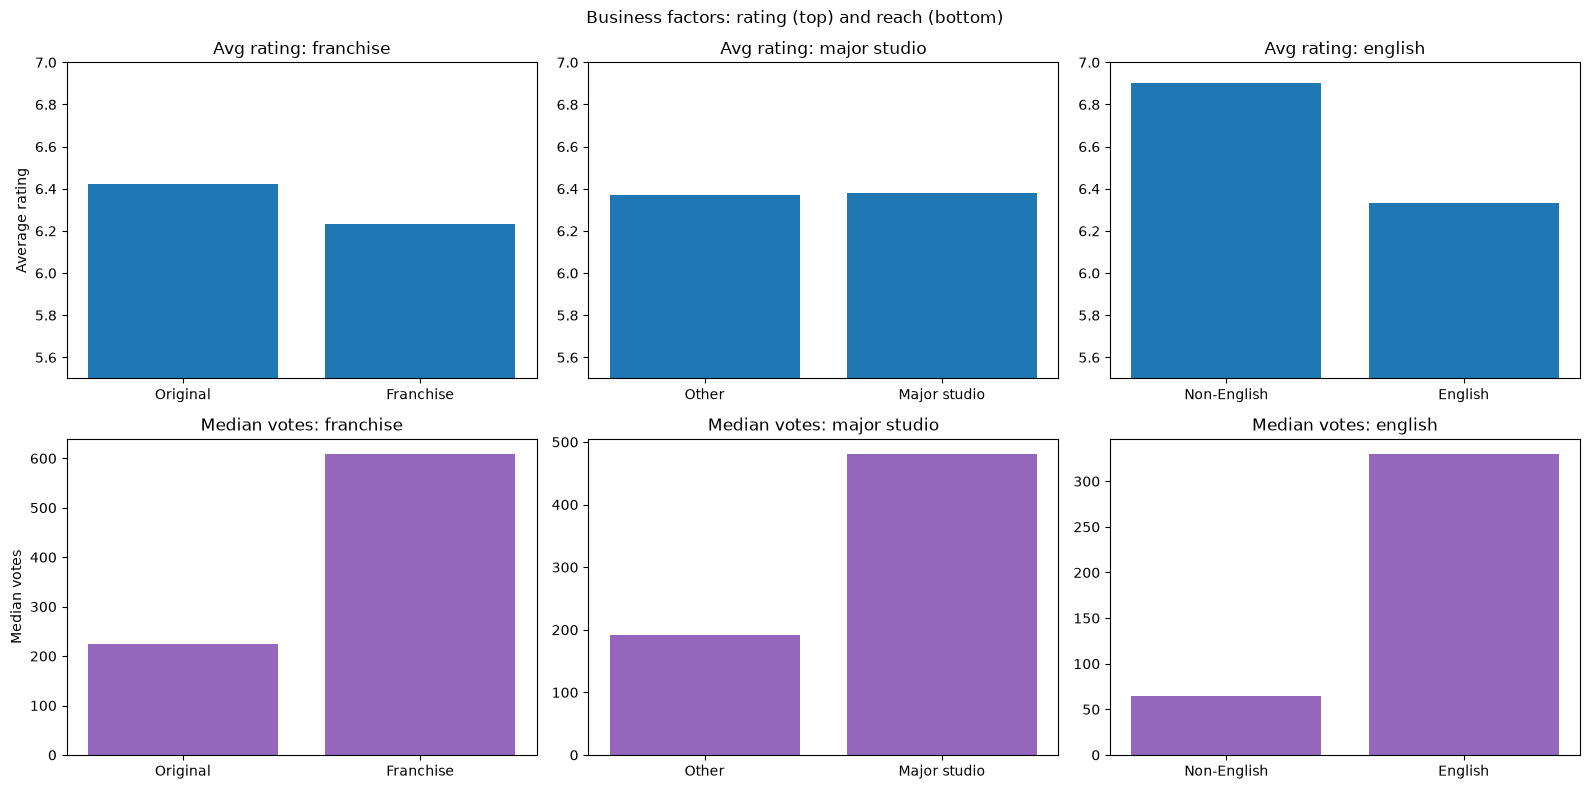

In [87]:
factors = [("is_franchise", ["Original", "Franchise"]),
           ("is_major_studio", ["Other", "Major studio"]),
           ("is_english", ["Non-English", "English"])]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, (col, labels) in enumerate(factors):
    r = rated.groupby(col)["vote_average"].mean()
    v = df.groupby(col)["vote_count"].median()
    axes[0, i].bar(labels, r.values, color="tab:blue")
    axes[0, i].set_ylim(5.5, 7); axes[0, i].set_title(f"Avg rating: {labels[1].lower()}")
    axes[1, i].bar(labels, v.values, color="tab:purple")
    axes[1, i].set_title(f"Median votes: {labels[1].lower()}")
axes[0, 0].set_ylabel("Average rating"); axes[1, 0].set_ylabel("Median votes")
plt.suptitle("Business factors: rating (top) and reach (bottom)")
plt.tight_layout(); plt.show()

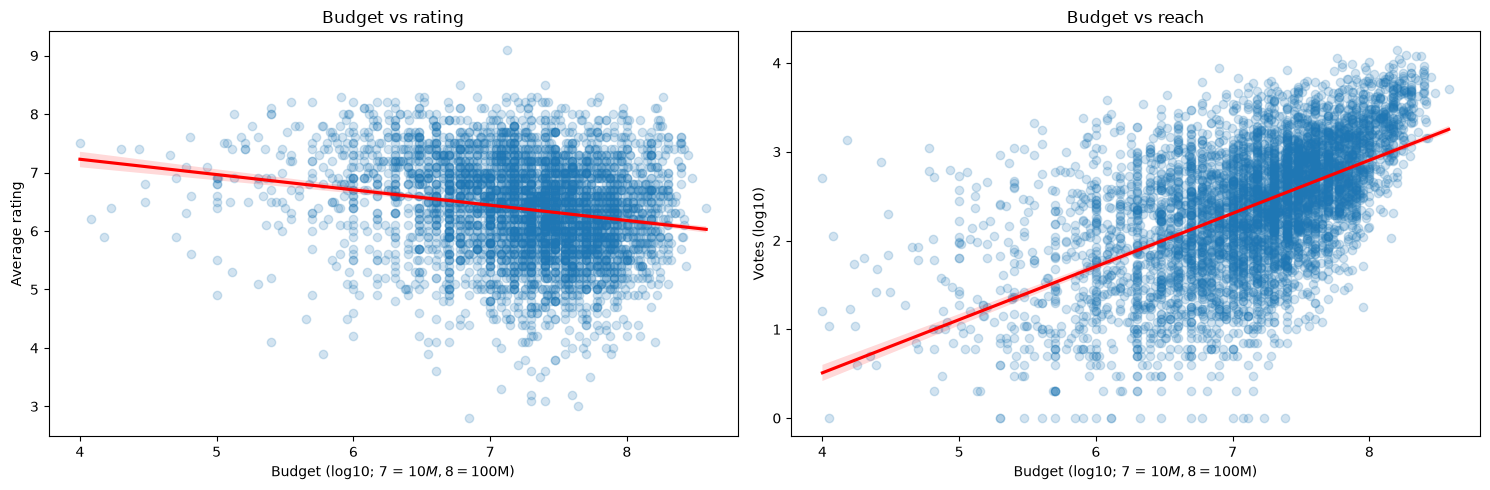

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.regplot(x=np.log10(rated["budget"]), y=rated["vote_average"], ax=axes[0],
            scatter_kws={"alpha": 0.2}, line_kws={"color": "red"})
axes[0].set_ylabel("Average rating"); axes[0].set_title("Budget vs rating")

sns.regplot(x=np.log10(df["budget"]), y=df["log_votes"], ax=axes[1],
            scatter_kws={"alpha": 0.2}, line_kws={"color": "red"})
axes[1].set_ylabel("Votes (log10)"); axes[1].set_title("Budget vs reach")

for ax in axes: ax.set_xlabel("Budget (log10; 7 = $10M, 8 = $100M)")
plt.tight_layout(); plt.show()

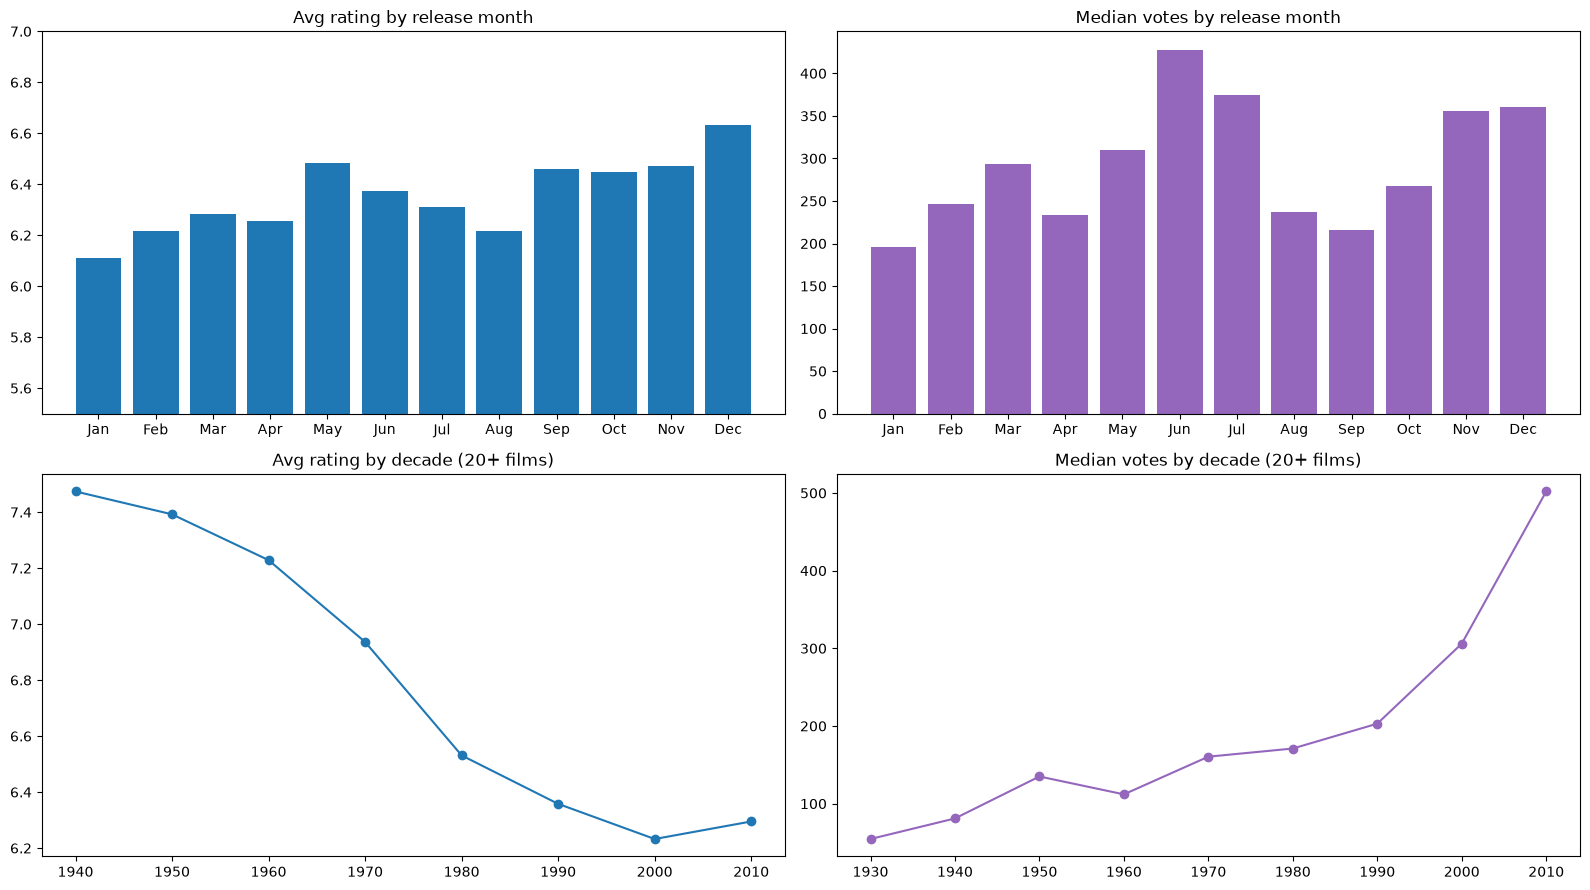

In [89]:
rated["decade"] = (rated["release_year"] // 10 * 10).astype(int)
df["decade"] = (df["release_year"] // 10 * 10).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes[0, 0].bar(month_names, rated.groupby("release_month")["vote_average"].mean(), color="tab:blue")
axes[0, 0].set_ylim(5.5, 7); axes[0, 0].set_title("Avg rating by release month")
axes[0, 1].bar(month_names, df.groupby("release_month")["vote_count"].median(), color="tab:purple")
axes[0, 1].set_title("Median votes by release month")

dec_r = rated.groupby("decade")["vote_average"].agg(["mean", "size"])
dec_v = df.groupby("decade")["vote_count"].agg(["median", "size"])
dec_r, dec_v = dec_r[dec_r["size"] >= 20], dec_v[dec_v["size"] >= 20]
axes[1, 0].plot(dec_r.index, dec_r["mean"], marker="o", color="tab:blue")
axes[1, 0].set_title("Avg rating by decade (20+ films)")
axes[1, 1].plot(dec_v.index, dec_v["median"], marker="o", color="tab:purple")
axes[1, 1].set_title("Median votes by decade (20+ films)")
plt.tight_layout(); plt.show()

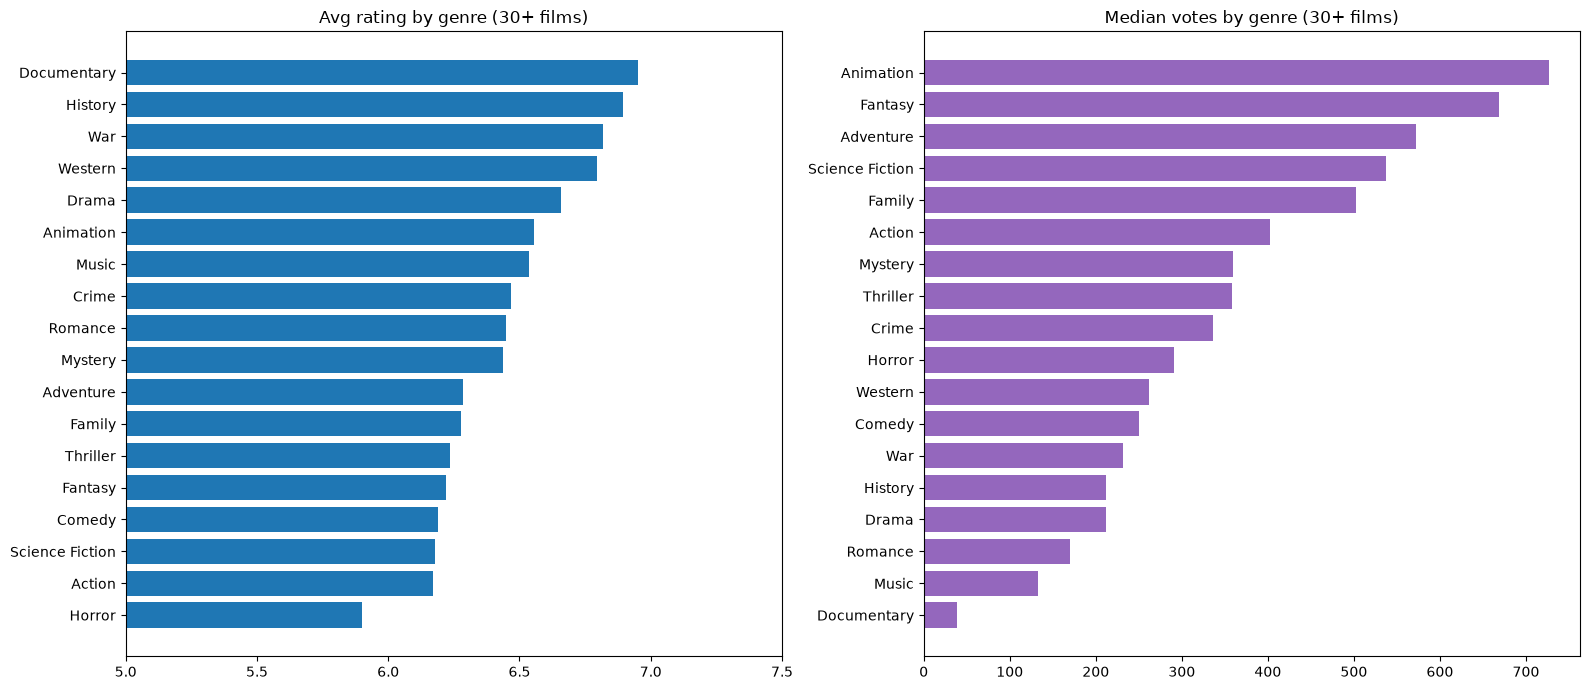

In [90]:
rows = []
for g in genre_cols:
    sub, sub_r = df[df[g] == 1], rated[rated[g] == 1]
    if len(sub) >= 30:
        rows.append({"genre": g, "avg_rating": sub_r["vote_average"].mean(),
                     "median_votes": sub["vote_count"].median(), "num_movies": len(sub)})
genre_aud = pd.DataFrame(rows).set_index("genre")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
gr = genre_aud.sort_values("avg_rating")
axes[0].barh(gr.index, gr["avg_rating"], color="tab:blue")
axes[0].set_xlim(5, 7.5); axes[0].set_title("Avg rating by genre (30+ films)")
gv = genre_aud.sort_values("median_votes")
axes[1].barh(gv.index, gv["median_votes"], color="tab:purple")
axes[1].set_title("Median votes by genre (30+ films)")
plt.tight_layout(); plt.show()

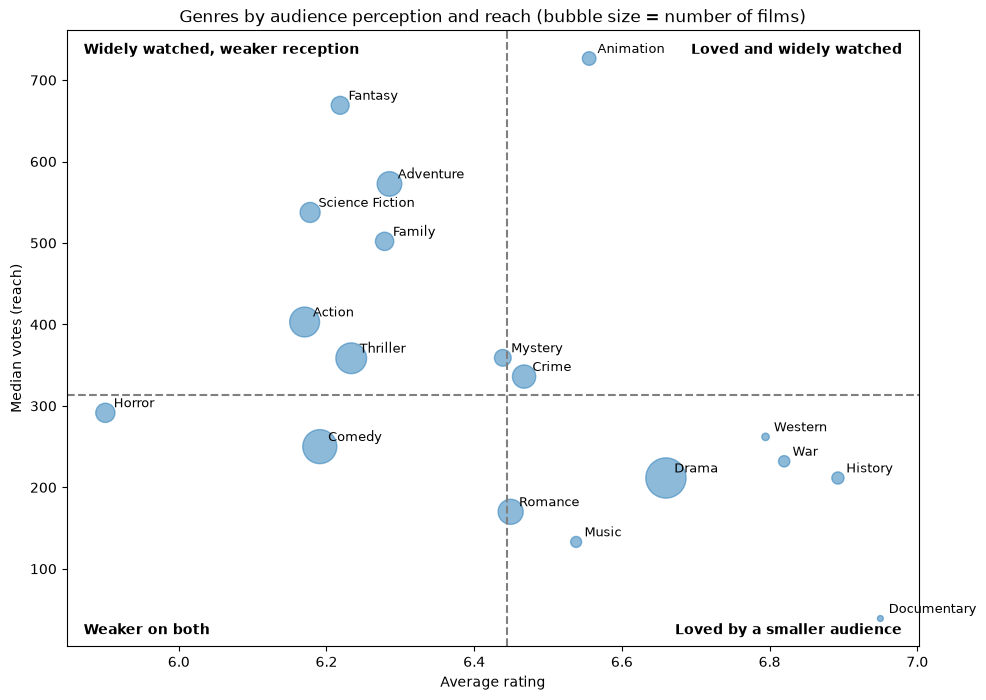

In [91]:
fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(genre_aud["avg_rating"], genre_aud["median_votes"],
           s=genre_aud["num_movies"] / 3, alpha=0.5)
for g, row in genre_aud.iterrows():
    ax.annotate(g, (row["avg_rating"], row["median_votes"]), xytext=(6, 4),
                textcoords="offset points", fontsize=9)
ax.axvline(genre_aud["avg_rating"].median(), color="gray", linestyle="--")
ax.axhline(genre_aud["median_votes"].median(), color="gray", linestyle="--")
ax.text(0.98, 0.98, "Loved and widely watched", transform=ax.transAxes, ha="right", va="top", fontweight="bold")
ax.text(0.02, 0.98, "Widely watched, weaker reception", transform=ax.transAxes, va="top", fontweight="bold")
ax.text(0.98, 0.02, "Loved by a smaller audience", transform=ax.transAxes, ha="right", fontweight="bold")
ax.text(0.02, 0.02, "Weaker on both", transform=ax.transAxes, fontweight="bold")
ax.set_xlabel("Average rating"); ax.set_ylabel("Median votes (reach)")
ax.set_title("Genres by audience perception and reach (bubble size = number of films)")
plt.show()

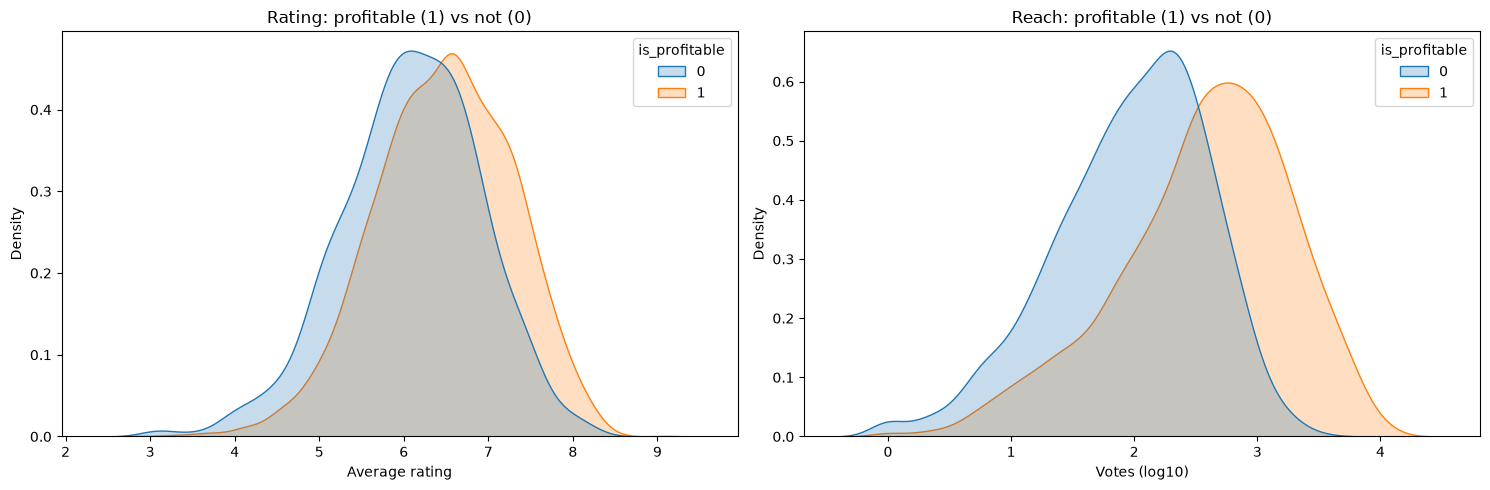

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.kdeplot(data=rated, x="vote_average", hue="is_profitable", common_norm=False, fill=True, ax=axes[0])
axes[0].set_title("Rating: profitable (1) vs not (0)")
axes[0].set_xlabel("Average rating")

sns.kdeplot(data=df, x="log_votes", hue="is_profitable", common_norm=False, fill=True, ax=axes[1])
axes[1].set_title("Reach: profitable (1) vs not (0)")
axes[1].set_xlabel("Votes (log10)")
plt.tight_layout(); plt.show()

In [93]:
def by_genre(data, value_col, min_films=30):
    """One row per (film, genre) pair, keeping genres with enough films."""
    long = data.melt(id_vars=[value_col], value_vars=genre_cols,
                     var_name="genre", value_name="has_genre")
    long = long[long["has_genre"] == 1]
    counts = long["genre"].value_counts()
    return long[long["genre"].isin(counts[counts >= min_films].index)]

aud["roi"] = aud["revenue"] / aud["budget"]

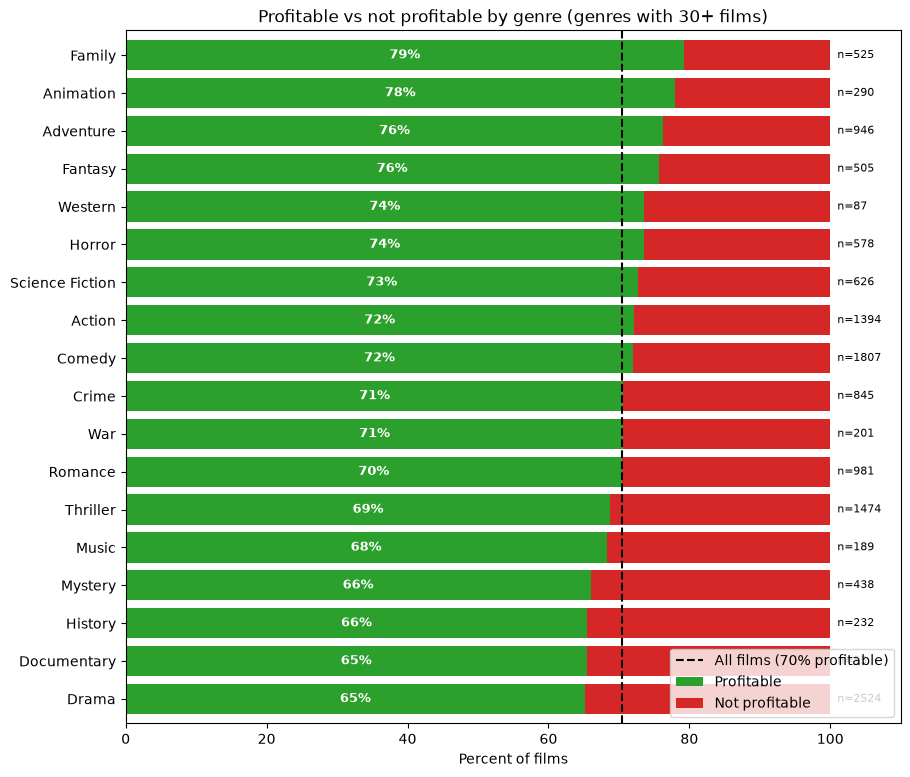

In [95]:
rows = []
for g in genre_cols:
    sub = aud[aud[g] == 1]
    if len(sub) >= 30:
        rows.append({"genre": g,
                     "Profitable": sub["is_profitable"].mean() * 100,
                     "Not profitable": (1 - sub["is_profitable"].mean()) * 100,
                     "n": len(sub)})

genre_split = pd.DataFrame(rows).set_index("genre").sort_values("Profitable")

ax = genre_split[["Profitable", "Not profitable"]].plot(
    kind="barh", stacked=True, figsize=(10, 9), color=["tab:green", "tab:red"], width=0.8)

for i, (genre, row) in enumerate(genre_split.iterrows()):
    ax.text(row["Profitable"] / 2, i, f"{row['Profitable']:.0f}%", va="center", ha="center",
            color="white", fontsize=9, fontweight="bold")
    ax.text(101, i, f"n={int(row['n'])}", va="center", fontsize=8)

overall = aud["is_profitable"].mean() * 100
ax.axvline(overall, color="black", linestyle="--", label=f"All films ({overall:.0f}% profitable)")
ax.set_xlim(0, 110)
ax.set_xlabel("Percent of films")
ax.set_ylabel("")
ax.set_title("Profitable vs not profitable by genre (genres with 30+ films)")
ax.legend(loc="lower right")
plt.show()

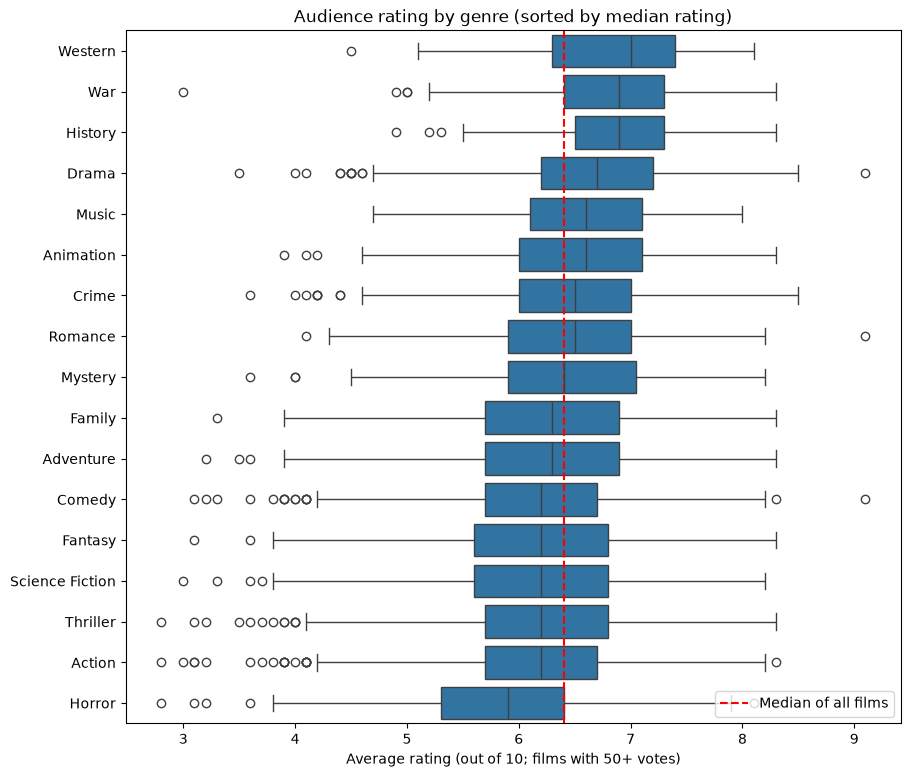

In [96]:
rating_long = by_genre(rated, "vote_average")
order = rating_long.groupby("genre")["vote_average"].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 9))
sns.boxplot(data=rating_long, y="genre", x="vote_average", order=order, color="tab:blue")
plt.axvline(rated["vote_average"].median(), color="red", linestyle="--", label="Median of all films")
plt.xlabel("Average rating (out of 10; films with 50+ votes)")
plt.ylabel("")
plt.title("Audience rating by genre (sorted by median rating)")
plt.legend(loc="lower right")
plt.show()